In [441]:
# load libraries
import pandas as pd
import numpy as np
# train test split
from sklearn.model_selection import train_test_split
# GridSearchCV - hyperparameter tuning
from sklearn.model_selection import GridSearchCV
# models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
import xgboost
# metrics
from sklearn.metrics import accuracy_score, log_loss
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, roc_auc_score
# data visualization
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree
import shap
import seaborn as sns


In [474]:
# Setting random seed for reproducibility
np.random.seed(42)

Import Data

In [475]:
url = "https://archive.ics.uci.edu/static/public/529/early+stage+diabetes+risk+prediction+dataset.zip"

df = pd.read_csv(url, compression='zip')
#df = pd.read_csv('../02_src/uci_diabetes.csv')

Data Cleaning

In [ ]:
# Binary encoding
binary_map = {"Yes": 1, "No": 0}
gender_map = {"Male": 0, "Female": 1}
class_map = {"Negative": 0, "Positive": 1}

# dropping demographic data and class (y variable)
symptom_cols = df.columns.drop(["Age", "Gender", "class"])

df[symptom_cols] = df[symptom_cols].replace(binary_map)
df["Gender"] = df["Gender"].replace(gender_map)
df["class"] = df["class"].replace(class_map)

# Placing Age in AgeGroup so they become categorical data
df['AgeGroup'] = pd.cut(df['Age'],
                        bins=[0,30,45,60,100],
                        labels=['<30','30–44','45–59','60+'])

# for these algorithms, we will not need the Age as an int
df = df.drop(columns=['Age'])

# Perform one-hot encoding on the 'AgeGroup' column
#  drop_first=True to avoid multicollinearity
df_encoded = pd.get_dummies(df, columns=['AgeGroup'], prefix='AgeGroup',  drop_first=True)

print(df_encoded.columns)


Index(['Gender', 'Polyuria', 'Polydipsia', 'sudden weight loss', 'weakness',
       'Polyphagia', 'Genital thrush', 'visual blurring', 'Itching',
       'Irritability', 'delayed healing', 'partial paresis',
       'muscle stiffness', 'Alopecia', 'Obesity', 'class', 'AgeGroup_30–44',
       'AgeGroup_45–59', 'AgeGroup_60+'],
      dtype='object')


C:\Users\shafe\AppData\Local\Temp\ipykernel_32632\3544833685.py:9: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df[symptom_cols] = df[symptom_cols].replace(binary_map)
C:\Users\shafe\AppData\Local\Temp\ipykernel_32632\3544833685.py:10: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df["Gender"] = df["Gender"].replace(gender_map)
C:\Users\shafe\AppData\Local\Temp\ipykernel_32632\3544833685.py:11: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, expli

In [477]:
# Target and Predictors
# target (y) dataset
target = df['class']
print(target)

# predictors dataset - X
df_data = df_encoded.drop(columns=['class'])
df_data

0      1
1      1
2      1
3      1
4      1
      ..
515    1
516    1
517    1
518    0
519    0
Name: class, Length: 520, dtype: int64


,Gender,Polyuria,Polydipsia,sudden weight loss,weakness,Polyphagia,Genital thrush,visual blurring,Itching,Irritability,delayed healing,partial paresis,muscle stiffness,Alopecia,Obesity,AgeGroup_30–44,AgeGroup_45–59,AgeGroup_60+
0,0,0,1,0,1,0,0,0,1,0,1,0,1,1,1,True,False,False
1,0,0,0,0,1,0,0,1,0,0,0,1,0,1,0,False,True,False
2,0,1,0,0,1,1,0,0,1,0,1,0,1,1,0,True,False,False
3,0,0,0,1,1,1,1,0,1,0,1,0,0,0,0,True,False,False
4,0,1,1,1,1,1,0,1,1,1,1,1,1,1,1,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
515,1,1,1,1,0,1,0,0,1,0,1,1,0,0,0,True,False,False
516,1,1,1,1,1,1,0,0,1,1,1,1,0,0,0,False,True,False
517,1,1,1,1,1,1,0,1,0,0,0,1,1,0,1,False,True,False
518,1,0,0,0,1,0,0,1,1,0,1,0,0,1,0,True,False,False


X and Y

In [478]:
X = df_data
y = target

In [479]:
# Train/Test Split (80% train, 20% test, stratify acros y and shuffle the dataset for randomness)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, shuffle= True, stratify = y,
) #

Subroutine that will be reused for evaluation

In [480]:
# subroutine for evaluation
# this subroutine will be re-used when testing multiple models
def evaluation(model, X_test, y_test):
    # testing
    y_pred = model.predict(X_test)

    print(classification_report(y_pred, y_test))

    # Evaluation
    # Get the default accuracy score
    accuracy = model.score(X_test, y_test)
    print(f"Accuracy Score: {accuracy}")

    # confusion matrix
    cm = confusion_matrix(y_test, y_pred)

    disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                                display_labels=model.classes_)
    disp.plot()
    plt.show()

    # Calculate the log loss
    y_pred_proba = model.predict_proba(X_test)
    loss = log_loss(y_test, y_pred_proba)

    print(f"Log Loss: {loss}")

Testing with Logistic Regression

              precision    recall  f1-score   support

           0       0.97      0.89      0.93        44
           1       0.92      0.98      0.95        60

    accuracy                           0.94       104
   macro avg       0.95      0.93      0.94       104
weighted avg       0.94      0.94      0.94       104

Accuracy Score: 0.9423076923076923


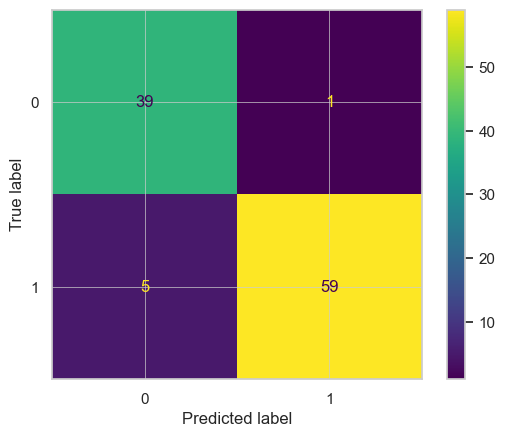

Log Loss: 0.15347693810880103


In [483]:
# Initialize
model = LogisticRegression()
# Train Model
model.fit(X_train, y_train) 

evaluation(model, X_test, y_test)

Decision Tree Classifier

              precision    recall  f1-score   support

           0       0.93      0.88      0.90        42
           1       0.92      0.95      0.94        62

    accuracy                           0.92       104
   macro avg       0.92      0.92      0.92       104
weighted avg       0.92      0.92      0.92       104

Accuracy Score: 0.9230769230769231


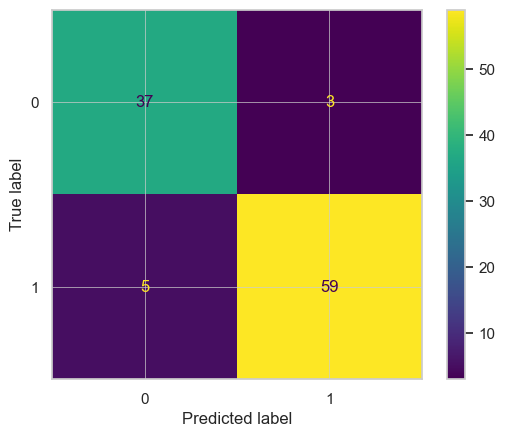

Log Loss: 2.438060929733802


In [485]:
# Initialize
model = DecisionTreeClassifier()
# Train model
model.fit(X_train, y_train)

evaluation(model, X_test, y_test)



Random Forest Classifier

              precision    recall  f1-score   support

           0       0.97      0.95      0.96        41
           1       0.97      0.98      0.98        63

    accuracy                           0.97       104
   macro avg       0.97      0.97      0.97       104
weighted avg       0.97      0.97      0.97       104

Accuracy Score: 0.9711538461538461


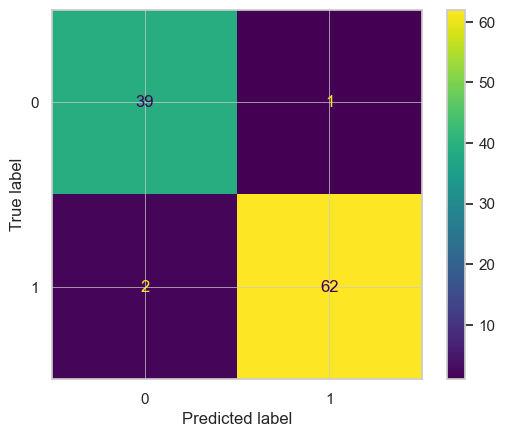

Log Loss: 0.06899900768078696


In [486]:
# Initialize the Random Forest Classifier
model = RandomForestClassifier(n_estimators=100, class_weight='balanced')

# Train the model
model.fit(X_train, y_train)

evaluation(model, X_test, y_test)

Log loss report seems most promising for random forest classifier so will perform hyperparameter tuning and further evaluation with random forest algorithm

In [487]:
# source https://www.geeksforgeeks.org/machine-learning/random-forest-hyperparameter-tuning-in-python/
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2],
    'bootstrap': [True, False]
}

# implement a grid search using GridSearchCV with 10-fold cross-validation
grid_search = GridSearchCV(RandomForestClassifier(class_weight='balanced'), param_grid=param_grid, cv=10)
grid_search.fit(X_train, y_train)

print("Best Parameters:", grid_search.best_params_)
print("Best Estimator:", grid_search.best_estimator_)

Best Parameters: {'bootstrap': True, 'max_depth': 10, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100}
Best Estimator: RandomForestClassifier(class_weight='balanced', max_depth=10)


Update the parameters of the model by those which are obtained by using GridSearchCV

              precision    recall  f1-score   support

           0       0.97      0.95      0.96        41
           1       0.97      0.98      0.98        63

    accuracy                           0.97       104
   macro avg       0.97      0.97      0.97       104
weighted avg       0.97      0.97      0.97       104

Accuracy Score: 0.9711538461538461


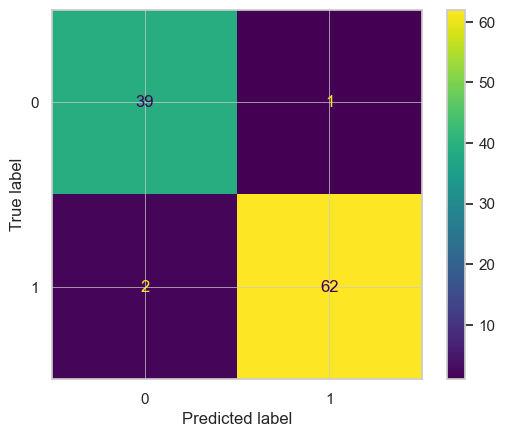

Log Loss: 0.07486415477748488


In [488]:
# using the values from the Best Estimator to recreate the Random Forest Classifier
model_grid = RandomForestClassifier(max_depth=grid_search.best_params_['max_depth'],
                                    n_estimators=grid_search.best_params_['n_estimators'],
                                    #bootstrap = grid_search.best_params_['bootstrap'],
                                    class_weight='balanced')
model_grid.fit(X_train, y_train)

evaluation(model_grid, X_test, y_test)


In [489]:
# printing the columns so could be referenced when asking the models questions
X.columns

Index(['Gender', 'Polyuria', 'Polydipsia', 'sudden weight loss', 'weakness',
       'Polyphagia', 'Genital thrush', 'visual blurring', 'Itching',
       'Irritability', 'delayed healing', 'partial paresis',
       'muscle stiffness', 'Alopecia', 'Obesity', 'AgeGroup_30–44',
       'AgeGroup_45–59', 'AgeGroup_60+'],
      dtype='object')

In [494]:
# predicting probabilities for each each symptom for different gender and age group
questions = [
            # Female
            [1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,False,False,False], # polyuria, <30
            [1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,True,False,False], # polyuria, AgeGroup_30–44
            [1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,False,True,False], # polyuria, AgeGroup_45–59
            [1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,False,False,True], # polyuria, AgeGroup_60+

            [1,0,1,0,0,0,0,0,0,0,0,0,0,0,0,False,False,False], # Polydipsia, <30
            [1,0,1,0,0,0,0,0,0,0,0,0,0,0,0,True,False,False], # Polydipsia, AgeGroup_30–44
            [1,0,1,0,0,0,0,0,0,0,0,0,0,0,0,False,True,False], # Polydipsia, AgeGroup_45–59
            [1,0,1,0,0,0,0,0,0,0,0,0,0,0,0,False,False,True], # Polydipsia, AgeGroup_60+

            [1,0,0,1,0,0,0,0,0,0,0,0,0,0,0,False,False,False], # sudden weight loss, <30
            [1,0,0,1,0,0,0,0,0,0,0,0,0,0,0,True,False,False], # sudden weight loss, AgeGroup_30–44
            [1,0,0,1,0,0,0,0,0,0,0,0,0,0,0,False,True,False], # sudden weight loss, AgeGroup_45–59
            [1,0,0,1,0,0,0,0,0,0,0,0,0,0,0,False,False,True], # sudden weight loss, AgeGroup_60+

            [1,0,0,0,1,0,0,0,0,0,0,0,0,0,0,False,False,False], # weakness, <30
            [1,0,0,0,1,0,0,0,0,0,0,0,0,0,0,True,False,False], # weakness, AgeGroup_30–44
            [1,0,0,0,1,0,0,0,0,0,0,0,0,0,0,False,True,False], # weakness, AgeGroup_45–59
            [1,0,0,0,1,0,0,0,0,0,0,0,0,0,0,False,False,True], # weakness, AgeGroup_60+

            [1,0,0,0,0,1,0,0,0,0,0,0,0,0,0,False,False,False], # Polyphagia, <30
            [1,0,0,0,0,1,0,0,0,0,0,0,0,0,0,True,False,False], # Polyphagia, AgeGroup_30–44
            [1,0,0,0,0,1,0,0,0,0,0,0,0,0,0,False,True,False], # Polyphagia, AgeGroup_45–59
            [1,0,0,0,0,1,0,0,0,0,0,0,0,0,0,False,False,True], # Polyphagia, AgeGroup_60+

            [1,0,0,0,0,0,1,0,0,0,0,0,0,0,0,False,False,False], # Genital thrush, <30
            [1,0,0,0,0,0,1,0,0,0,0,0,0,0,0,True,False,False], # Genital thrush, AgeGroup_30–44
            [1,0,0,0,0,0,1,0,0,0,0,0,0,0,0,False,True,False], # Genital thrush, AgeGroup_45–59
            [1,0,0,0,0,0,1,0,0,0,0,0,0,0,0,False,False,True], # Genital thrush, AgeGroup_60+

            
            [1,0,0,0,0,0,0,1,0,0,0,0,0,0,0,False,False,False], # visual blurring, <30
            [1,0,0,0,0,0,0,1,0,0,0,0,0,0,0,True,False,False], # visual blurring, AgeGroup_30–44
            [1,0,0,0,0,0,0,1,0,0,0,0,0,0,0,False,True,False], # visual blurring, AgeGroup_45–59
            [1,0,0,0,0,0,0,1,0,0,0,0,0,0,0,False,False,True], # visual blurring, AgeGroup_60+

            [1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,False,False,False], # Itching, <30
            [1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,True,False,False], # Itching, AgeGroup_30–44
            [1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,False,True,False], # Itching, AgeGroup_45–59
            [1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,False,False,True], # Itching, AgeGroup_60+

            [1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,False,False,False], # Irritability, <30
            [1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,True,False,False], # Irritability, AgeGroup_30–44
            [1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,False,True,False], # Irritability, AgeGroup_45–59
            [1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,False,False,True], # Irritability, AgeGroup_60+

            [1,0,0,0,0,0,0,0,0,0,1,0,0,0,0,False,False,False], # delayed healing, <30
            [1,0,0,0,0,0,0,0,0,0,1,0,0,0,0,True,False,False], # delayed healing, AgeGroup_30–44
            [1,0,0,0,0,0,0,0,0,0,1,0,0,0,0,False,True,False], # delayed healing, AgeGroup_45–59
            [1,0,0,0,0,0,0,0,0,0,1,0,0,0,0,False,False,True], # delayed healing, AgeGroup_60+

            [1,0,0,0,0,0,0,0,0,0,0,1,0,0,0,False,False,False], # partial paresi, <30
            [1,0,0,0,0,0,0,0,0,0,0,1,0,0,0,True,False,False], # partial paresi, AgeGroup_30–44
            [1,0,0,0,0,0,0,0,0,0,0,1,0,0,0,False,True,False], # partial paresi, AgeGroup_45–59
            [1,0,0,0,0,0,0,0,0,0,0,1,0,0,0,False,False,True], # partial paresi, AgeGroup_60+

            [1,0,0,0,0,0,0,0,0,0,0,0,1,0,0,False,False,False], # muscle stiffness, <30
            [1,0,0,0,0,0,0,0,0,0,0,0,1,0,0,True,False,False], # muscle stiffness, AgeGroup_30–44
            [1,0,0,0,0,0,0,0,0,0,0,0,1,0,0,False,True,False], # muscle stiffness, AgeGroup_45–59
            [1,0,0,0,0,0,0,0,0,0,0,0,1,0,0,False,False,True], # muscle stiffness, AgeGroup_60+

            
            [1,0,0,0,0,0,0,0,0,0,0,0,0,1,0,False,False,False], # Alopecia, <30
            [1,0,0,0,0,0,0,0,0,0,0,0,0,1,0,True,False,False], # Alopecia, AgeGroup_30–44
            [1,0,0,0,0,0,0,0,0,0,0,0,0,1,0,False,True,False], # Alopecia, AgeGroup_45–59
            [1,0,0,0,0,0,0,0,0,0,0,0,0,1,0,False,False,True], # Alopecia, AgeGroup_60+

            [1,0,0,0,0,0,0,0,0,0,0,0,0,0,1,False,False,False], # Obesity, <30
            [1,0,0,0,0,0,0,0,0,0,0,0,0,0,1,True,False,False], # Obesity, AgeGroup_30–44
            [1,0,0,0,0,0,0,0,0,0,0,0,0,0,1,False,True,False], # Obesity, AgeGroup_45–59
            [1,0,0,0,0,0,0,0,0,0,0,0,0,0,1,False,False,True], # Obesity, AgeGroup_60+

            # Male
            [0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,False,False,False], # polyuria, <30
            [0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,True,False,False], # polyuria, AgeGroup_30–44
            [0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,False,True,False], # polyuria, AgeGroup_45–59
            [0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,False,False,True], # polyuria, AgeGroup_60+

            [0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,False,False,False], # Polydipsia, <30
            [0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,True,False,False], # Polydipsia, AgeGroup_30–44
            [0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,False,True,False], # Polydipsia, AgeGroup_45–59
            [0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,False,False,True], # Polydipsia, AgeGroup_60+

            [0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,False,False,False], # sudden weight loss, <30
            [0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,True,False,False], # sudden weight loss, AgeGroup_30–44
            [0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,False,True,False], # sudden weight loss, AgeGroup_45–59
            [0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,False,False,True], # sudden weight loss, AgeGroup_60+

            [0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,False,False,False], # weakness, <30
            [0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,True,False,False], # weakness, AgeGroup_30–44
            [0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,False,True,False], # weakness, AgeGroup_45–59
            [0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,False,False,True], # weakness, AgeGroup_60+

            [0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,False,False,False], # Polyphagia, <30
            [0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,True,False,False], # Polyphagia, AgeGroup_30–44
            [0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,False,True,False], # Polyphagia, AgeGroup_45–59
            [0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,False,False,True], # Polyphagia, AgeGroup_60+

            [0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,False,False,False], # Genital thrush, <30
            [0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,True,False,False], # Genital thrush, AgeGroup_30–44
            [0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,False,True,False], # Genital thrush, AgeGroup_45–59
            [0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,False,False,True], # Genital thrush, AgeGroup_60+

            
            [0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,False,False,False], # visual blurring, <30
            [0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,True,False,False], # visual blurring, AgeGroup_30–44
            [0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,False,True,False], # visual blurring, AgeGroup_45–59
            [0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,False,False,True], # visual blurring, AgeGroup_60+

            [0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,False,False,False], # Itching, <30
            [0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,True,False,False], # Itching, AgeGroup_30–44
            [0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,False,True,False], # Itching, AgeGroup_45–59
            [0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,False,False,True], # Itching, AgeGroup_60+

            [0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,False,False,False], # Irritability, <30
            [0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,True,False,False], # Irritability, AgeGroup_30–44
            [0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,False,True,False], # Irritability, AgeGroup_45–59
            [0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,False,False,True], # Irritability, AgeGroup_60+

            [0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,False,False,False], # delayed healing, <30
            [0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,True,False,False], # delayed healing, AgeGroup_30–44
            [0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,False,True,False], # delayed healing, AgeGroup_45–59
            [0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,False,False,True], # delayed healing, AgeGroup_60+

            [0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,False,False,False], # partial paresi, <30
            [0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,True,False,False], # partial paresi, AgeGroup_30–44
            [0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,False,True,False], # partial paresi, AgeGroup_45–59
            [0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,False,False,True], # partial paresi, AgeGroup_60+

            [0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,False,False,False], # muscle stiffness, <30
            [0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,True,False,False], # muscle stiffness, AgeGroup_30–44
            [0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,False,True,False], # muscle stiffness, AgeGroup_45–59
            [0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,False,False,True], # muscle stiffness, AgeGroup_60+

            
            [0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,False,False,False], # Alopecia, <30
            [0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,True,False,False], # Alopecia, AgeGroup_30–44
            [0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,False,True,False], # Alopecia, AgeGroup_45–59
            [0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,False,False,True], # Alopecia, AgeGroup_60+

            [0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,False,False,False], # Obesity, <30
            [0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,True,False,False], # Obesity, AgeGroup_30–44
            [0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,False,True,False], # Obesity, AgeGroup_45–59
            [0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,False,False,True], # Obesity, AgeGroup_60+
            ]
probability = model_grid.predict_proba(questions)

# Create a data frame with result for easier analysis
data = {
    'Symptom': [
        # Female
                'Polyuria', 'Polyuria', 'Polyuria', 'Polyuria',
                'Polydipsia', 'Polydipsia', 'Polydipsia', 'Polydipsia',
                'sudden weight loss', 'sudden weight loss', 'sudden weight loss', 'sudden weight loss',
                'weakness', 'weakness', 'weakness', 'weakness',
                'Polyphagia', 'Polyphagia', 'Polyphagia', 'Polyphagia',
                'Genital thrush', 'Genital thrush', 'Genital thrush', 'Genital thrush',
                'visual blurring', 'visual blurring', 'visual blurring', 'visual blurring',
                'Itching', 'Itching', 'Itching', 'Itching',
                'Irritability', 'Irritability', 'Irritability', 'Irritability',
                'delayed healing', 'delayed healing', 'delayed healing', 'delayed healing',
                'partial paresi', 'partial paresi', 'partial paresi', 'partial paresi',
                'muscle stiffness', 'muscle stiffness', 'muscle stiffness', 'muscle stiffness',
                'Alopecia', 'Alopecia', 'Alopecia', 'Alopecia',
                'Obesity', 'Obesity', 'Obesity', 'Obesity',
        # Male
                'Polyuria', 'Polyuria', 'Polyuria', 'Polyuria',
                'Polydipsia', 'Polydipsia', 'Polydipsia', 'Polydipsia',
                'sudden weight loss', 'sudden weight loss', 'sudden weight loss', 'sudden weight loss',
                'weakness', 'weakness', 'weakness', 'weakness',
                'Polyphagia', 'Polyphagia', 'Polyphagia', 'Polyphagia',
                'Genital thrush', 'Genital thrush', 'Genital thrush', 'Genital thrush',
                'visual blurring', 'visual blurring', 'visual blurring', 'visual blurring',
                'Itching', 'Itching', 'Itching', 'Itching',
                'Irritability', 'Irritability', 'Irritability', 'Irritability',
                'delayed healing', 'delayed healing', 'delayed healing', 'delayed healing',
                'partial paresi', 'partial paresi', 'partial paresi', 'partial paresi',
                'muscle stiffness', 'muscle stiffness', 'muscle stiffness', 'muscle stiffness',
                'Alopecia', 'Alopecia', 'Alopecia', 'Alopecia',
                'Obesity', 'Obesity', 'Obesity', 'Obesity',
                ],
    'Gender': [
                'Female', 'Female', 'Female', 'Female', #0
                'Female', 'Female', 'Female', 'Female', #1
                'Female', 'Female', 'Female', 'Female', #2
                'Female', 'Female', 'Female', 'Female', #3
                'Female', 'Female', 'Female', 'Female', #4
                'Female', 'Female', 'Female', 'Female', #5
                'Female', 'Female', 'Female', 'Female', #6
                'Female', 'Female', 'Female', 'Female', #7
                'Female', 'Female', 'Female', 'Female', #8
                'Female', 'Female', 'Female', 'Female', #9
                'Female', 'Female', 'Female', 'Female', #10
                'Female', 'Female', 'Female', 'Female', #11
                'Female', 'Female', 'Female', 'Female', #12
                'Female', 'Female', 'Female', 'Female', #13

                'Male', 'Male', 'Male', 'Male', #0
                'Male', 'Male', 'Male', 'Male', #1
                'Male', 'Male', 'Male', 'Male', #2
                'Male', 'Male', 'Male', 'Male', #3
                'Male', 'Male', 'Male', 'Male', #4
                'Male', 'Male', 'Male', 'Male', #5
                'Male', 'Male', 'Male', 'Male', #6
                'Male', 'Male', 'Male', 'Male', #7
                'Male', 'Male', 'Male', 'Male', #8
                'Male', 'Male', 'Male', 'Male', #9
                'Male', 'Male', 'Male', 'Male', #10
                'Male', 'Male', 'Male', 'Male', #11
                'Male', 'Male', 'Male', 'Male', #12
                'Male', 'Male', 'Male', 'Male', #13
            ],
    'Age Group': [
                '<30', '30–44', '45–59', '60+',
                '<30', '30–44', '45–59', '60+',
                '<30', '30–44', '45–59', '60+',
                '<30', '30–44', '45–59', '60+',
                '<30', '30–44', '45–59', '60+',
                '<30', '30–44', '45–59', '60+',
                '<30', '30–44', '45–59', '60+',
                '<30', '30–44', '45–59', '60+',
                '<30', '30–44', '45–59', '60+',
                '<30', '30–44', '45–59', '60+',
                '<30', '30–44', '45–59', '60+',
                '<30', '30–44', '45–59', '60+',
                '<30', '30–44', '45–59', '60+',
                '<30', '30–44', '45–59', '60+',
                # Male
                '<30', '30–44', '45–59', '60+',
                '<30', '30–44', '45–59', '60+',
                '<30', '30–44', '45–59', '60+',
                '<30', '30–44', '45–59', '60+',
                '<30', '30–44', '45–59', '60+',
                '<30', '30–44', '45–59', '60+',
                '<30', '30–44', '45–59', '60+',
                '<30', '30–44', '45–59', '60+',
                '<30', '30–44', '45–59', '60+',
                '<30', '30–44', '45–59', '60+',
                '<30', '30–44', '45–59', '60+',
                '<30', '30–44', '45–59', '60+',
                '<30', '30–44', '45–59', '60+',
                '<30', '30–44', '45–59', '60+',
                ],
    'Probability_1':[
        # Female
                    round(probability[0][1] * 100, 2), round(probability[1][1] * 100, 2), round(probability[2][1] * 100, 2), round(probability[3][1] * 100, 2),
                    round(probability[4][1] * 100, 2),  round(probability[5][1] * 100, 2), round(probability[6][1] * 100, 2), round(probability[7][1] * 100, 2),
                    round(probability[8][1] * 100, 2),  round(probability[9][1] * 100, 2), round(probability[10][1] * 100, 2), round(probability[11][1] * 100, 2),
                    round(probability[12][1] * 100, 2), round( probability[13][1] * 100, 2), round(probability[14][1] * 100, 2), round(probability[15][1] * 100, 2),
                    round(probability[16][1] * 100, 2),  round(probability[17][1] * 100, 2), round(probability[18][1] * 100, 2), round(probability[19][1] * 100, 2),
                    round(probability[20][1] * 100, 2),  round(probability[21][1] * 100, 2), round(probability[22][1] * 100, 2), round(probability[23][1] * 100, 2),
                    round(probability[24][1] * 100, 2),  round(probability[25][1] * 100, 2), round(probability[26][1] * 100, 2), round(probability[27][1] * 100, 2),
                    round(probability[28][1] * 100, 2),  round(probability[29][1] * 100, 2), round(probability[30][1] * 100, 2), round(probability[31][1] * 100, 2),
                    round(probability[32][1] * 100, 2),  round(probability[33][1] * 100, 2), round(probability[34][1] * 100, 2), round(probability[35][1] * 100, 2),
                    round(probability[36][1] * 100, 2),  round(probability[37][1] * 100, 2), round(probability[38][1] * 100, 2), round(probability[39][1] * 100, 2),
                    round(probability[40][1] * 100, 2),  round(probability[41][1] * 100, 2), round(probability[42][1] * 100, 2), round(probability[43][1] * 100, 2),
                    round(probability[44][1] * 100, 2),  round(probability[45][1] * 100, 2), round(probability[46][1] * 100, 2), round(probability[47][1]* 100, 2),
                    round(probability[48][1] * 100, 2),  round(probability[49][1] * 100, 2), round(probability[50][1] * 100, 2), round(probability[51][1] * 100, 2),
                    round(probability[52][1] * 100, 2),  round(probability[53][1] * 100, 2), round(probability[54][1] * 100, 2), round(probability[55][1] * 100, 2),
        # Male
                    round(probability[56][1] * 100, 2),  round(probability[57][1] * 100, 2), round(probability[58][1] * 100, 2), round(probability[59][1] * 100, 2),
                    round(probability[60][1] * 100, 2),  round(probability[61][1] * 100, 2), round(probability[62][1] * 100, 2), round(probability[63][1] * 100, 2),
                    round(probability[64][1] * 100, 2),  round(probability[65][1] * 100, 2), round(probability[66][1] * 100, 2), round(probability[67][1] * 100, 2),
                    round(probability[68][1] * 100, 2),  round(probability[69][1] * 100, 2), round(probability[70][1] * 100, 2), round(probability[71][1] * 100, 2),
                    round(probability[72][1] * 100, 2),  round(probability[73][1] * 100, 2), round(probability[74][1] * 100, 2), round(probability[75][1] * 100, 2),
                    round(probability[76][1] * 100, 2),  round(probability[77][1] * 100, 2), round(probability[78][1] * 100, 2), round(probability[79][1] * 100, 2),
                    round(probability[80][1] * 100, 2),  round(probability[81][1] * 100, 2), round(probability[82][1] * 100, 2), round(probability[83][1] * 100, 2),
                    round(probability[84][1] * 100, 2),  round(probability[85][1] * 100, 2), round(probability[86][1] * 100, 2), round(probability[87][1] * 100, 2),
                    round(probability[88][1] * 100, 2),  round(probability[89][1] * 100, 2), round(probability[90][1] * 100, 2), round(probability[91][1] * 100, 2),
                    round(probability[92][1] * 100, 2),  round(probability[93][1] * 100, 2), round(probability[94][1] * 100, 2), round(probability[95][1] * 100, 2),
                    round(probability[96][1] * 100, 2),  round(probability[97][1] * 100, 2), round(probability[98][1] * 100, 2), round(probability[99][1] * 100, 2),
                    round(probability[100][1] * 100, 2),  round(probability[101][1] * 100, 2), round(probability[102][1] * 100, 2), round(probability[103][1] * 100, 2),
                    round(probability[104][1] * 100, 2),  round(probability[105][1] * 100, 2), round(probability[106][1] * 100, 2), round(probability[107][1] * 100, 2),
                    round(probability[108][1] * 100, 2), round(probability[109][1] * 100, 2), round(probability[110][1] * 100, 2), round(probability[111][1] * 100, 2),
                    ],
}

df_probability = pd.DataFrame(data)
df_probability

c:\Users\shafe\Documents\DSI\ds4\ds4\ds4-env\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


,Symptom,Gender,Age Group,Probability_1
0,Polyuria,Female,<30,86.58
1,Polyuria,Female,30–44,81.35
2,Polyuria,Female,45–59,90.93
3,Polyuria,Female,60+,91.10
4,Polydipsia,Female,<30,88.18
...,...,...,...,...
107,Alopecia,Male,60+,19.10
108,Obesity,Male,<30,7.14
109,Obesity,Male,30–44,13.16
110,Obesity,Male,45–59,10.84


In [495]:
# printing top symptoms based on predicted probability
# since predicted probability differs based on gender and age group, we will use the median to average
# the top 5 predictors will be placed in our flyer
top_symptoms = df_probability.groupby("Symptom")["Probability_1"].median().sort_values(ascending=False)
print(top_symptoms)

Symptom
Polydipsia            85.370
Polyuria              79.050
delayed healing       50.925
Obesity               47.975
visual blurring       46.460
partial paresi        45.055
muscle stiffness      42.995
Genital thrush        40.170
Polyphagia            33.660
weakness              31.790
Itching               31.675
Irritability          31.645
Alopecia              29.785
sudden weight loss    20.660
Name: Probability_1, dtype: float64


In [ ]:
# write the data for analysis
# uncomment if would like to export the data as csv
# for example, you may wish to analyze the result in excel
#df_probability.to_csv('output.csv')

Generating Graphs to show trends. 

In [550]:
# Combination tests
# predicting probabilities for various scenarios
# the 3 Ps - hallmark sign in diabetes
questions = [
            [1, 1,1,0,0,0,0,0,0,0,0,0,0,0,0,False,False,False], # polyuria + Polydipsia + Polyphagia, <30
            [1, 1,1,0,0,0,0,0,0,0,0,0,0,0,0,True,False,False], # polyuria + Polydipsia + Polyphagia,AgeGroup_30–44
            [1, 1,1,0,0,0,0,0,0,0,0,0,0,0,0,False,True,False], # polyuria + Polydipsia + Polyphagia,, AgeGroup_45–59
            [1, 1,1,0,0,0,0,0,0,0,0,0,0,0,0,False,False,True], # polyuria + Polydipsia + Polyphagia, AgeGroup_60+

            [0, 1,1,0,0,0,0,0,0,0,0,0,0,0,0,False,False,False], # polyuria + Polydipsia + Polyphagia, <30
            [0, 1,1,0,0,0,0,0,0,0,0,0,0,0,0,True,False,False], # polyuria + Polydipsia + Polyphagia,AgeGroup_30–44
            [0, 1,1,0,0,0,0,0,0,0,0,0,0,0,0,False,True,False], # polyuria + Polydipsia + Polyphagia,, AgeGroup_45–59
            [0, 1,1,0,0,0,0,0,0,0,0,0,0,0,0,False,False,True], # polyuria + Polydipsia + Polyphagia, AgeGroup_60+
]

probability_list = model_grid.predict_proba(questions)

# since percentage is more reader friendly will convert the probability to percent and round to 2 decimal places
probability = [round(prob * 100, 2) for prob in probability_list[:, 1]]


data = {
    'AgeGroup': ['<30', '30–44', '45–59', '60+',
                '<30', '30–44', '45–59', '60+',],
    'Sex': ['Female','Female','Female', 'Female',
                'Male', 'Male', 'Male', 'Male'],
    'Percentage':  probability,
}

df_probability_3ps = pd.DataFrame(data)
df_probability_3ps


c:\Users\shafe\Documents\DSI\ds4\ds4\ds4-env\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


,AgeGroup,Sex,Percentage
0,<30,Female,95.98
1,30–44,Female,94.63
2,45–59,Female,96.84
3,60+,Female,97.81
4,<30,Male,96.08
5,30–44,Male,97.08
6,45–59,Male,97.65
7,60+,Male,98.00


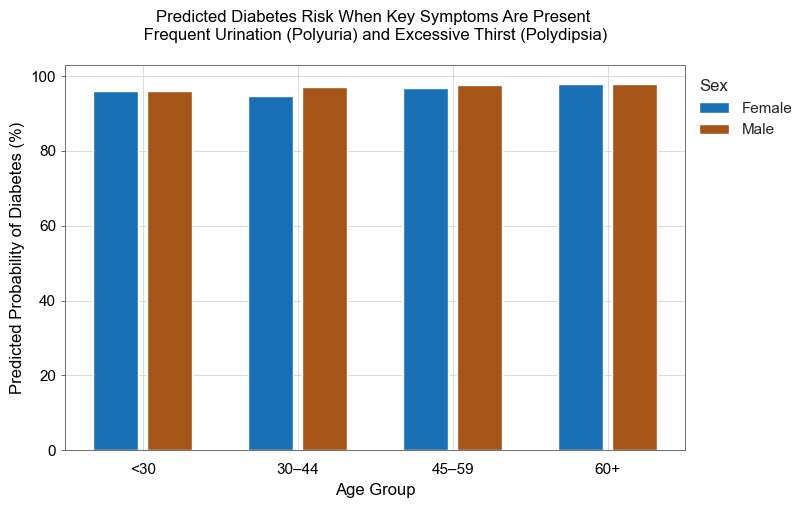

In [560]:
# Plot
# This graph is used in our flyer, so will put some extra effor to make it look good
custom_palette = ["#0073CF", "#BD5200"]
# style="whitegrid"
sns.set_theme(style='whitegrid', palette=custom_palette)

sns.set_context("notebook", rc={"grid.linewidth": 0.5})

plt.figure(figsize=(8,5))
ax = sns.barplot(
    data=df_probability_3ps,
    x="AgeGroup",
    y="Percentage",
    hue="Sex",
    width=0.7,
    gap=0.175,
)

plt.title("Predicted Diabetes Risk When Key Symptoms Are Present \n Frequent Urination (Polyuria) and Excessive Thirst (Polydipsia) \n", color="black")
plt.ylabel("Predicted Probability of Diabetes (%)", color="black")
plt.xlabel("Age Group", color="black")
#plt.ylim(90, 100)   # optional, helps highlight differences
ax.grid(True, axis='both')

plt.legend(title="Sex", labelcolor='black', alignment='left', frameon=False)

# Set the color of individual spines
# set to 0.5 if decided to show the percentage
ax.spines['left'].set_color('#363333')
ax.spines['bottom'].set_color('#363333')
ax.spines['right'].set_color('#363333') 
ax.spines['top'].set_color('#363333')

ax.spines['left'].set_linewidth(0.5) 
ax.spines['bottom'].set_linewidth(0.5) 
ax.spines['right'].set_linewidth(0.5) 
ax.spines['top'].set_linewidth(0.5) 


sns.move_legend(ax, "upper left", bbox_to_anchor=(1, 1))

ax.tick_params(
    axis='y',    # Affects both major and minor ticks
    left=True,       # Show ticks on the left axis
    direction='out',  # Ticks face inward
    length=3,        # Length of minor ticks
    color='#363333',     # Color of minor ticks
    width=0.5,
)

ax.tick_params(axis='both', labelcolor='black')

#ax.set_yticklabels([])
#ax.grid(False)

plt.show()

In [532]:
# partial paresi & muscle stiffness
questions = [
            [1, 0,0,0,0,0,0,0,0,0,0,1,1,0,0,False,False,False], # partial paresi + muscle stiffness, <30
            [1, 0,0,0,0,0,0,0,0,0,0,1,1,0,0,True,False,False], # partial paresi + muscle stiffness,AgeGroup_30–44
            [1, 0,0,0,0,0,0,0,0,0,0,1,1,0,0,False,True,False], # partial paresi + muscle stiffness,, AgeGroup_45–59
            [1, 0,0,0,0,0,0,0,0,0,0,1,1,0,0,False,False,True], # partial paresi + muscle stiffness, AgeGroup_60+

            [0, 0,0,0,0,0,0,0,0,0,0,1,1,0,0,False,False,False], # partial paresi + muscle stiffness, <30
            [0, 0,0,0,0,0,0,0,0,0,0,1,1,0,0,True,False,False], # partial paresi + muscle stiffness,AgeGroup_30–44
            [0, 0,0,0,0,0,0,0,0,0,0,1,1,0,0,False,True,False], # partial paresi + muscle stiffness,, AgeGroup_45–59
            [0, 0,0,0,0,0,0,0,0,0,0,1,1,0,0,False,False,True], # partial paresi + muscle stiffness, AgeGroup_60+
]

# partial paresi and muscle stiffness	
probability_list = model_grid.predict_proba(questions)


probability = [round(prob * 100, 2) for prob in probability_list[:, 1]]


data = {
    'AgeGroup': ['<30', '30–44', '45–59', '60+',
                '<30', '30–44', '45–59', '60+',],
    'Gender': ['Female','Female','Female', 'Female',
                'Male', 'Male', 'Male', 'Male'],
    'Percentage':  probability,
}

df_probability_paresi_muscle_stiffness = pd.DataFrame(data)
df_probability_paresi_muscle_stiffness



c:\Users\shafe\Documents\DSI\ds4\ds4\ds4-env\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


,AgeGroup,Gender,Percentage
0,<30,Female,69.60
1,30–44,Female,74.03
2,45–59,Female,66.00
3,60+,Female,74.72
4,<30,Male,21.56
5,30–44,Male,27.32
6,45–59,Male,13.00
7,60+,Male,32.56


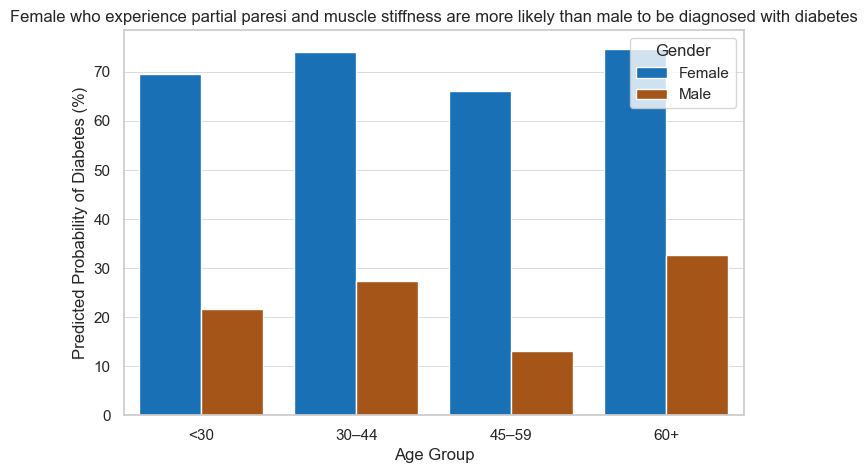

In [533]:
# Plot
plt.figure(figsize=(8,5))

sns.barplot(
    data=df_probability_paresi_muscle_stiffness,
    x="AgeGroup",
    y="Percentage",
    hue="Gender"
)

plt.title("Female who experience partial paresi and muscle stiffness are more likely than male to be diagnosed with diabetes")
plt.xlabel("Age Group")
plt.ylabel("Predicted Probability of Diabetes (%)")
plt.legend(title="Gender")

plt.show()

In [534]:
questions = [
            [1, 0,0,0,0,0,1,0,0,0,0,0,0,0,0,False,False,False], # polyuria + Polydipsia + Polyphagia, <30
            [1, 0,0,0,0,0,1,0,0,0,0,0,0,0,0,True,False,False], # polyuria + Polydipsia + Polyphagia,AgeGroup_30–44
            [1, 0,0,0,0,0,1,0,0,0,0,0,0,0,0,False,True,False], # polyuria + Polydipsia + Polyphagia,, AgeGroup_45–59
            [1, 0,0,0,0,0,1,0,0,0,0,0,0,0,0,False,False,True], # polyuria + Polydipsia + Polyphagia, AgeGroup_60+

            [0, 0,0,0,0,0,1,0,0,0,0,0,0,0,0,False,False,False], # polyuria + Polydipsia + Polyphagia, <30
            [0, 0,0,0,0,0,1,0,0,0,0,0,0,0,0,True,False,False], # polyuria + Polydipsia + Polyphagia,AgeGroup_30–44
            [0, 0,0,0,0,0,1,0,0,0,0,0,0,0,0,False,True,False], # polyuria + Polydipsia + Polyphagia,, AgeGroup_45–59
            [0, 0,0,0,0,0,1,0,0,0,0,0,0,0,0,False,False,True], # polyuria + Polydipsia + Polyphagia, AgeGroup_60+
]

probability_list = model_grid.predict_proba(questions)
print(probability_list[:, 1].mean())

probability = [round(prob * 100, 2) for prob in probability_list[:, 1]]


data = {
    'AgeGroup': ['<30', '30–44', '45–59', '60+',
                '<30', '30–44', '45–59', '60+',],
    'Gender': ['Female','Female','Female', 'Female',
                'Male', 'Male', 'Male', 'Male'],
    'Percentage':  probability,
}

df_probability_genital_thrush = pd.DataFrame(data)
df_probability_genital_thrush

0.429048364976009


c:\Users\shafe\Documents\DSI\ds4\ds4\ds4-env\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


,AgeGroup,Gender,Percentage
0,<30,Female,69.58
1,30–44,Female,58.07
2,45–59,Female,74.06
3,60+,Female,87.94
4,<30,Male,9.38
5,30–44,Male,9.83
6,45–59,Male,12.10
7,60+,Male,22.27


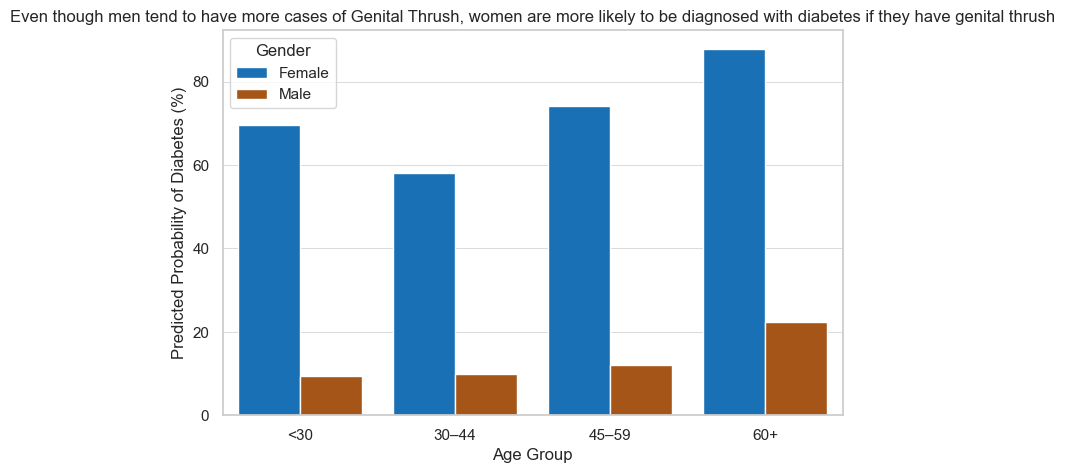

In [535]:
# Ensure logical age order
age_order = ["<30","30–44","45–59","60+"]
df_probability_genital_thrush["AgeGroup"] = pd.Categorical(df_probability_genital_thrush["AgeGroup"], categories=age_order, ordered=True)

# Plot
plt.figure(figsize=(8,5))

ax = sns.barplot(
    data=df_probability_genital_thrush,
    x="AgeGroup",
    y="Percentage",
    hue="Gender"
)

plt.title("Even though men tend to have more cases of Genital Thrush, women are more likely to be diagnosed with diabetes if they have genital thrush")
plt.xlabel("Age Group")
plt.ylabel("Predicted Probability of Diabetes (%)")
plt.legend(title="Gender")

plt.show()

In [536]:
questions = [
            [1, 0,0,0,0,0,0,0,0,0,0,0,0,0,1,False,False,False], # polyuria + Polydipsia + Polyphagia, <30
            [1, 0,0,0,0,0,0,0,0,0,0,0,0,0,1,True,False,False], # polyuria + Polydipsia + Polyphagia,AgeGroup_30–44
            [1, 0,0,0,0,0,0,0,0,0,0,0,0,0,1,False,True,False], # polyuria + Polydipsia + Polyphagia,, AgeGroup_45–59
            [1, 0,0,0,0,0,0,0,0,0,0,0,0,0,1,False,False,True], # polyuria + Polydipsia + Polyphagia, AgeGroup_60+

]

probability_list = model_grid.predict_proba(questions)
print(probability_list[:, 1].mean())

probability = [round(prob * 100, 2) for prob in probability_list[:, 1]]


data = {
    'AgeGroup': ['<30', '30–44', '45–59', '60+'],
    'Gender': ['Female','Female','Female', 'Female'],
    'Percentage':  probability,
}

df_probability_obesity = pd.DataFrame(data)
df_probability_obesity

0.8070959682721004


c:\Users\shafe\Documents\DSI\ds4\ds4\ds4-env\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


,AgeGroup,Gender,Percentage
0,<30,Female,76.85
1,30–44,Female,78.61
2,45–59,Female,82.04
3,60+,Female,85.34


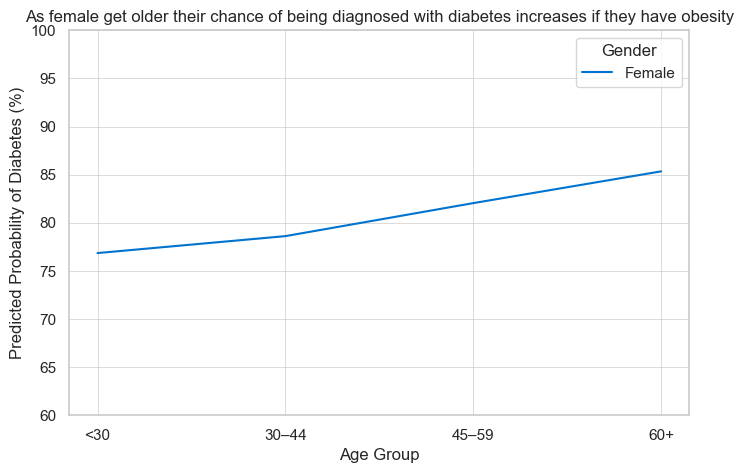

In [537]:
# Ensure logical age order
age_order = ["<30","30–44","45–59","60+"]
df_probability_obesity["AgeGroup"] = pd.Categorical(df_probability_obesity["AgeGroup"], categories=age_order, ordered=True)

# Plot
plt.figure(figsize=(8,5))

ax = sns.lineplot(
    data=df_probability_obesity,
    x="AgeGroup",
    y="Percentage",
    hue="Gender"
)
plt.ylim(60, 100)   # optional, helps highlight differences

plt.title("As female get older their chance of being diagnosed with diabetes increases if they have obesity")
plt.xlabel("Age Group")
plt.ylabel("Predicted Probability of Diabetes (%)")
plt.legend(title="Gender")

plt.show()

Analysis of Model - Attempt at Explainability

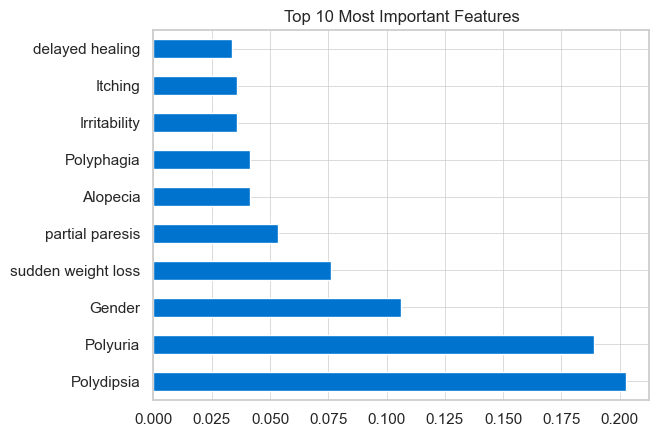

In [538]:
# Create a Series with feature importances
importances = pd.Series(model_grid.feature_importances_, index=X.columns)
importances.nlargest(10).plot(kind='barh') # top 10
plt.title("Top 10 Most Important Features")
plt.show()

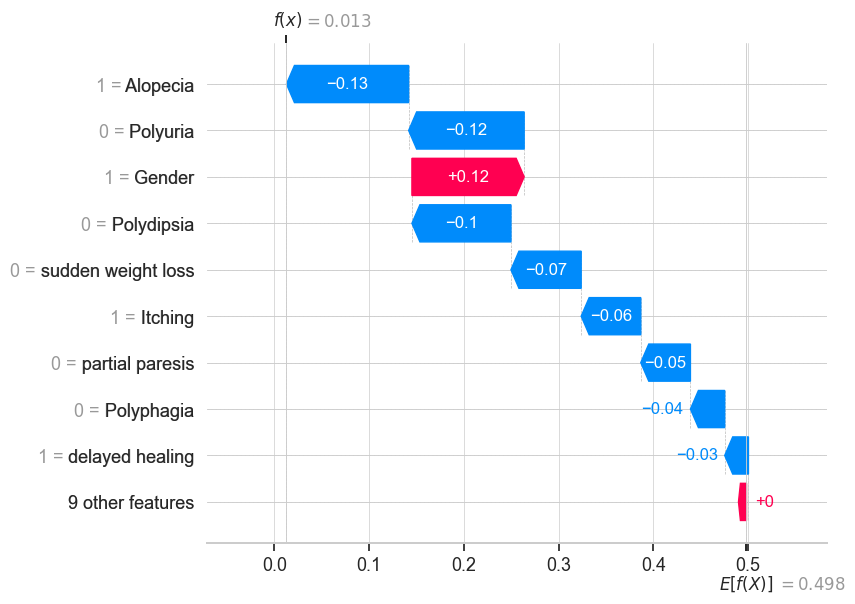

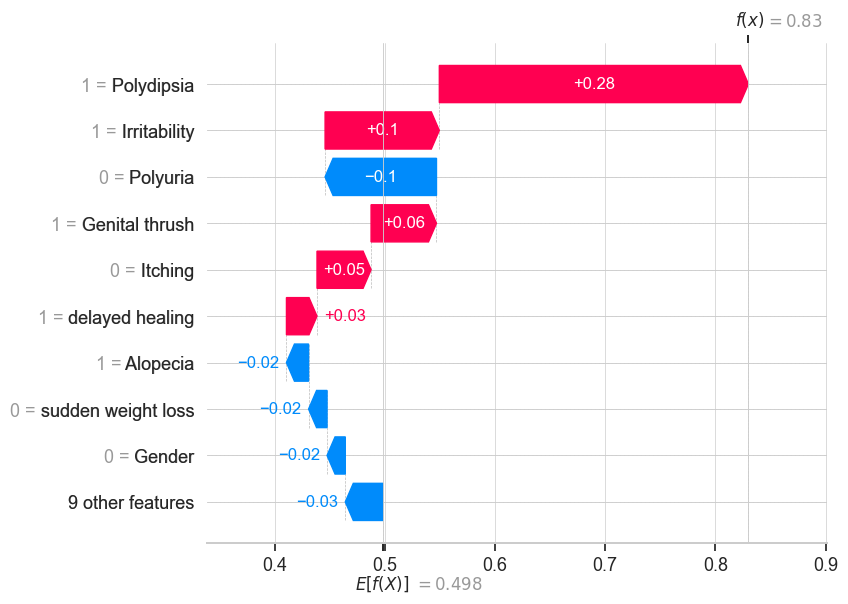

In [540]:
# SHAP
# TreeExplainer is highly optimized for Random Forests
explainer = shap.TreeExplainer(model_grid)
shap_values = explainer(X_test) # Calculate SHAP values for the test set

# Local Explanation: Waterfall Plot
# Shows why the model made a specific prediction (e.g., for the first test row)
# Note: For classification, we specify index [:, :, 1] for the 'Positive' class
shap.plots.waterfall(shap_values[0, :, 1])
shap.plots.waterfall(shap_values[1, :, 1])

C:\Users\shafe\AppData\Local\Temp\ipykernel_32632\2980575129.py:1: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values[:, :, 1], X_test)


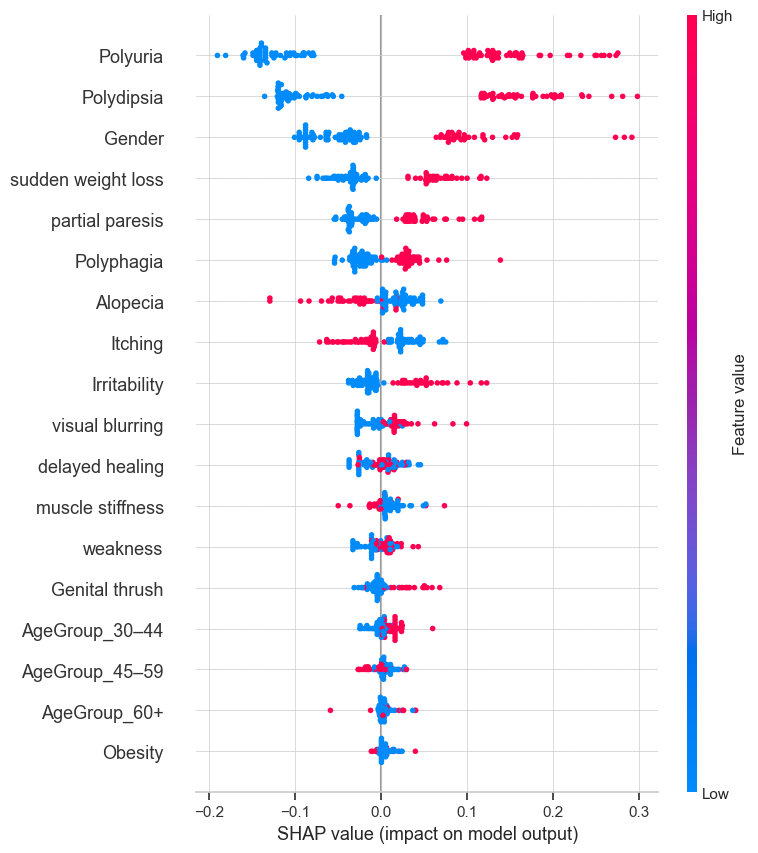

In [543]:
shap.summary_plot(shap_values[:, :, 1], X_test)
# based on the result the model may need further improvement or calibration - future improvement